<a href="https://colab.research.google.com/github/vldls-ul/sofonisba_leonardo/blob/main/progetto_dataset_storicoartistico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Humanities e Data Management / Informatica per i Beni Culturali (2025/2026)

# Analisi di un dataset storico-artistico

# 1. Introduzione

Il nostro gruppo di lavoro è formato da Bagnolini Matilde, Valdifiori Alessia e Villani Sofia. Abbiamo lavorato sul Dataset storico-artistico perché più affine al percorso di studi intrapreso. Abbiamo infatti scelto di esplorare, pulire e studiare i dati inerenti a questo argomento che ormai da cinque anni ci appassiona. Oltre all'analisi abbiamo scelto di creare alcuni grafici per una visione più veloce e più immediata del lavoro svolto.



### 1.1 Obiettivi

Abbiamo voluto indagare due particolari aspetti del Dataset ovvero il genere e i movimenti artistici, mettendoli in relazione alla collezione di appartenenza e al periodo, fondamentale per la genesi e la defizione dell'opera stessa. Per quanto riguarda la domanda sul genere abbiamo scelto di individuare quale di quelli riportati nel Dataset fosse stato il più fortunato, per poi concentrarci sul ritratto, genere che persiste nei secoli. Andando avanti con il lavoro sono sorte ulteriori domande in merito alla collocazione di queste opere e come ultima indagine abbiamo preso in cosiderazione il movimento artistico a cui queste appartenevano, scoprendo anche chi erano gli artisti più produttivi.

Con questo progetto le domande a cui abbiamo cercato di rispondere sono le seguenti:
* Qual è stato l'anno in cui sono state realizzate più opere d'arte?
* Quali sono stati i generi più fortunati?
* Quale collezione ospita più ritratti?
* Quali sono stati i movimenti artistici più prolifici?
* Chi ha creato il maggior numero di opere d'arte per ogni movimento?


### 1.2 Dati utilizzati
I dati in input sono costituiti da un file CSV fornito (https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv).

I dati in output consistono in questo Notebook, contenente testo e codice per l'analisi dei dati.

| Variabile | Tipo | Definizione | Esempio |
| :------- | :--- | :--------- | :------ |
| id | String | Identificativo univoco dell'opera d'arte. | http://www.wikidata.org/entity/Q428274 |
| titolo | String | Titolo dell'opera d'arte. | ritratto di fedra inghirami, detto fedra |
| artisti | String | Nome dell'artista o degli artisti che hanno creato l'opera. | raffaello sanzio (maschio) |
| data_creazione | Int64 | Anno di creazione dell'opera d'arte. | 1510 |
| generi | String | Genere o generi a cui appartiene l'opera. | ritratto; nudo artistico; pittura mitologica |
| luoghi | String | Luogo(i) associato(i) all'opera (es. dove è stata creata o esposta). | galleria palatina |
| collezioni | String | Nome della collezione o delle collezioni in cui l'opera è conservata. | galleria palatina |
| contenuti | String | Descrizione dei contenuti principali dell'opera. | libro; carta; scrittura; strabismo; posizione del braccio; uomo |
| movimenti | String | Movimento artistico o corrente a cui l'opera appartiene. | rinascimento |
| soggetti | String | Soggetto o soggetti raffigurati nell'opera. | tommaso inghirami |
| altezza | Float64 | Altezza dell'opera in metri. | 0.910 |
| larghezza | Float64 | Larghezza dell'opera in metri. | 0.610 |


### 1.3 Organizzazione

Abbiamo lavorato su GoogleColab partendo dal dataset storico-artistico fornito. Abbiamo lavorato in gruppo confrontandoci sempre nelle scelte dei metodi da seguire.


### 1.4 Preservazione

Per la preservazione del progetto e dei dati analizzati abbiamo usato le piattaforme GitHub e Zenodo.

### 1.5 Accesso e Utilizzo
La licenza del progetto è la Creative Commons Zero - CC0

https://creativecommons.org/publicdomain/zero/1.0/

# 2. Struttura

Il primo step è stato l'ispezione e la pulizia del Dataset, successivamente abbiamo suddiviso l'analisi dei dati in base alla data, ai generi e ai movimenti. Con i risultati ottenuti abbiamo creato i grafici, per poi passare alle conclusioni finali.

1. Introduzione
2. Struttura
3. Caricamento e ispezione dei dati
4. Processamento dei dati
5. Analisi dei dati
6. Conclusioni

# 3. Caricamento e ispezione dei dati

Nello specifico abbiamo importato pandas, creato il dataframe principale dal CSV e abbiamo studiato le prime informazioni contenute nel dataframe.

In [ ]:
import pandas as pd
url_database = "https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/vapod/data.csv"

df = pd.read_csv(url_database)

Abbiamo osservato le dimensioni con il metodo **.shape()** ottenendo che il dataframe è costituito da 2444 righe e 12 colonne; con **.columns()** abbiamo estrapolato le denominazioni di ogni singola colonna. Per avere una visione generale del dataframe analizzato abbiamo utilizzato il metodo **.info()** che mostra, oltre alle informazioni già visualizzate in precedenza, anche le quantità di valori non nulli e la tipologia di dati contenuta nelle colonne. Come ultima cosa abbiamo visualizzato le prime e ultime cinque righe del dataframe con i metodi **.head()** e **.tail()**.

In [ ]:
df.shape

(2444, 12)

In [ ]:
df.columns

Index(['id', 'titolo', 'artisti', 'data_creazione', 'generi', 'luoghi',
       'collezioni', 'contenuti', 'movimenti', 'soggetti', 'altezza',
       'larghezza'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   object 
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
dtypes: float64(2), object(10)
memory usage: 229.3+ KB


In [ ]:
df.head()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/Q428274,"Ritratto di Fedra Inghirami, detto Fedra",Raffaello Sanzio (maschio),1510,ritratto,Galleria Palatina,Galleria Palatina,libro; carta; scrittura; strabismo; posizione ...,Alto Rinascimento,Tommaso Inghirami,91.0,61.0
1,http://www.wikidata.org/entity/Q151047,Nascita di Venere,Sandro Botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,Palazzo degli Uffizi,mare; donna; cielo; vento; albero; Afrodite; c...,Rinascimento; Primo Rinascimento,Venere Anadiomene; nascita di Afrodite,172.5,278.5
2,http://www.wikidata.org/entity/Q180632,Ritratto di Paolo III con i nipoti Alessandro ...,Tiziano Vecellio (maschio),1546,ritratto; ritratto di gruppo,Museo nazionale di Capodimonte,Museo nazionale di Capodimonte,tavolo; tenda; papa Paolo III; Ottavio Farnese...,manierismo; pittura veneta,papa Paolo III,210.0,176.0
3,http://www.wikidata.org/entity/Q368788,Pietà,Perugino (maschio),1483,arte religiosa,Palazzo degli Uffizi,Palazzo degli Uffizi,Gesù; donna; Maria; uomo,rinascimento italiano,Pietà,168.0,176.0
4,http://www.wikidata.org/entity/Q549847,Primavera,Sandro Botticelli (maschio),1480,allegoria; pittura mitologica,Palazzo Medici Riccardi; Galleria delle pittur...,Palazzo degli Uffizi,mela; donna; fiore; Mercurio; primavera; Cupid...,Primo Rinascimento,primavera,207.0,319.0


In [ ]:
df.tail()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
2439,http://www.wikidata.org/entity/Q136934711,Venere e Satiro,Lambert Sustris (maschio),1600,nudo artistico; pittura mitologica,NaN,NaN,donna; uomo; nudità; barba; foglia; Venere; te...,NaN,NaN,102.0,131.0
2440,http://www.wikidata.org/entity/Q136747345,Ritratto del cardinale Antonio Agliardi,Giuseppe Riva (pittore 1861-1948) (maschio),1898,ritratto,Palazzo Frizzoni,Accademia Carrara; Palazzo Frizzoni,Antonio Agliardi,NaN,Antonio Agliardi,140.0,112.0
2441,http://www.wikidata.org/entity/Q136789581,Scena amorosa,NaN,1600,arte di genere,Casa Buonarroti,Casa Buonarroti,donna; uomo; partner,pittura veneta,NaN,74.5,66.5
2442,http://www.wikidata.org/entity/Q136849352,San Benedetto Revelli,NaN,1700,arte religiosa,chiesa di Santa Maria in Fontibus,chiesa di Santa Maria in Fontibus,Benedetto Revelli,NaN,Benedetto Revelli,220.0,150.0
2443,http://www.wikidata.org/entity/Q137169658,"Ritratto di fanciulla, ""Violante""",Giovanni Cariani (maschio),1600,ritratto,Galleria Estense,Galleria Estense,parapetto; donna giovane,pittura veneta; Alto Rinascimento,donna giovane,90.0,65.0


# 4. Processamento dei dati
Con il metodo **.strip()** abbiamo rimosso gli spazi vuoti e con **.lower()** abbiamo convertito colonne e valori testuali in minuscolo per pulire e uniformare i dati contenuti nel dataframe. Abbiamo poi ricontrollato le prime cinque per controllare il lavoro appena svolto.

In [ ]:
df.columns = df.columns.str.strip().str.lower()

for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip().str.lower()

In [ ]:
df.head()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/q428274,"ritratto di fedra inghirami, detto fedra",raffaello sanzio (maschio),1510,ritratto,galleria palatina,galleria palatina,libro; carta; scrittura; strabismo; posizione ...,alto rinascimento,tommaso inghirami,91.0,61.0
1,http://www.wikidata.org/entity/q151047,nascita di venere,sandro botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,palazzo degli uffizi,mare; donna; cielo; vento; albero; afrodite; c...,rinascimento; primo rinascimento,venere anadiomene; nascita di afrodite,172.5,278.5
2,http://www.wikidata.org/entity/q180632,ritratto di paolo iii con i nipoti alessandro ...,tiziano vecellio (maschio),1546,ritratto; ritratto di gruppo,museo nazionale di capodimonte,museo nazionale di capodimonte,tavolo; tenda; papa paolo iii; ottavio farnese...,manierismo; pittura veneta,papa paolo iii,210.0,176.0
3,http://www.wikidata.org/entity/q368788,pietà,perugino (maschio),1483,arte religiosa,palazzo degli uffizi,palazzo degli uffizi,gesù; donna; maria; uomo,rinascimento italiano,pietà,168.0,176.0
4,http://www.wikidata.org/entity/q549847,primavera,sandro botticelli (maschio),1480,allegoria; pittura mitologica,palazzo medici riccardi; galleria delle pittur...,palazzo degli uffizi,mela; donna; fiore; mercurio; primavera; cupid...,primo rinascimento,primavera,207.0,319.0


Con il metodo **.info()** avevamo visto che la tipologia della colonna "data_creazione" risultava essere **"object"**, insolito siccome dovrebbe risultare come **"int64"**.

Successivamente, abbiamo visualizzato il contenuto della colonna "data_creazione".

In [ ]:
df['data_creazione']

,data_creazione
0,1510
1,1485
2,1546
3,1483
4,1480
...,...
2439,1600
2440,1898
2441,1600
2442,1700


Con **.iloc[]** abbiamo osservato un insieme di righe scelte casualmente che però hanno evidenziato nella colonna "data_creazione" la presenza di intervalli di date con la barra verticale **(pipe; |)** ossia le righe 443 e 444.

In [ ]:
df.iloc[440:450]

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
440,http://www.wikidata.org/entity/q46833514,ritratto del duca louis de clève,jean clouet (maschio),1530,ritratto,accademia carrara,accademia carrara; collezione lochis,NaN,rinascimento francese; primitivi fiamminghi,NaN,24.0,20.7
441,http://www.wikidata.org/entity/q48808515,pietà,cosmè tura (maschio),1460,arte religiosa,museo correr,museo correr,gesù; pietà,NaN,pietà,48.0,33.0
442,http://www.wikidata.org/entity/q48388241,ritratto virile,giovanni bellini (maschio),1490,ritratto,pinacoteca capitolina,musei capitolini,NaN,NaN,uomo,34.0,26.5
443,http://www.wikidata.org/entity/q48917755,vanitas,mattia preti (maschio),1650 | 1670,arte religiosa,palazzo degli uffizi,palazzo degli uffizi,maria maddalena,barocco,NaN,93.5,65.0
444,http://www.wikidata.org/entity/q49167697,morte di lucrezia,francesco rustici (maschio),1624 | 1625,pittura storica,palazzo degli uffizi,palazzo degli uffizi,lucrezia,barocco,suicidio di lucrezia,175.0,259.5
445,http://www.wikidata.org/entity/q48814933,ritratto di giovane ignota,agnolo bronzino (maschio),1545,ritratto,NaN,palazzo degli uffizi,ragazza,NaN,NaN,58.0,46.5
446,http://www.wikidata.org/entity/q48927682,santi giovanni evangelista e francesco,el greco (maschio),1600,arte religiosa,palazzo degli uffizi,palazzo degli uffizi,francesco d'assisi; giovanni,manierismo,NaN,110.0,86.5
447,http://www.wikidata.org/entity/q49167284,allegoria della pittura e architettura,francesco rustici (maschio),1620,allegoria,palazzo degli uffizi,palazzo degli uffizi,architettura; pittura,barocco,NaN,129.7,97.0
448,http://www.wikidata.org/entity/q49167493,maria maddalena morente,francesco rustici (maschio),1624,arte religiosa,palazzo degli uffizi,palazzo degli uffizi,maria maddalena; angeli,barocco,NaN,121.0,169.5
449,http://www.wikidata.org/entity/q49167869,ritratto di jacopo sansovino,jacopo tintoretto (maschio),1566,ritratto,palazzo degli uffizi,palazzo degli uffizi,jacopo sansovino,manierismo; pittura veneta,jacopo sansovino,70.0,65.5


Abbiamo convertito i valori della colonna "data_creazione" in stringhe con la dicitura **df['data_creazione'].astype(str)**, in modo da poter semplicficare i passaggi successivi.

Con il metodo **.str.split(' | ')** abbiamo diviso ogni stringa della colonna in due sottostringhe indentificabili con la barra verticale.

Con **.str[0]** abbiamo preso solamente il primo anno indicato nell'intervallo e poi abbiamo convertito il contenuto testuale in numero decimale con **.astype('float')** in quanto ci consente di gestire meglio eventuali valori mancanti o formati non perfettamente numerici. Questo è stato un passaggio intermedio che ha facilitato lo svolgimento generale della conversione.

Infine abbiamo convertito il valore ottenuto in numero intero col metodo **.astype('Int64')** in modo da riusicre a gestire, oltre che i singoli numeri interi, anche eventuali valori nulli.

Abbiamo quindi rivisualizzato le prime righe del DataFrame e le informazioni generali per vedere le modifiche apportate.

In [ ]:
df['data_creazione'] = df['data_creazione'].astype(str).str.split(' | ').str[0].astype(float).astype('Int64')
display(df['data_creazione'].head())
display(df['data_creazione'].info())

,data_creazione
0,1510
1,1485
2,1546
3,1483
4,1480


<class 'pandas.core.series.Series'>
RangeIndex: 2444 entries, 0 to 2443
Series name: data_creazione
Non-Null Count  Dtype
--------------  -----
1478 non-null   Int64
dtypes: Int64(1)
memory usage: 21.6 KB


None

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2444 entries, 0 to 2443
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2444 non-null   object 
 1   titolo          2444 non-null   object 
 2   artisti         2159 non-null   object 
 3   data_creazione  1478 non-null   Int64  
 4   generi          1524 non-null   object 
 5   luoghi          2362 non-null   object 
 6   collezioni      2236 non-null   object 
 7   contenuti       2021 non-null   object 
 8   movimenti       382 non-null    object 
 9   soggetti        1666 non-null   object 
 10  altezza         1281 non-null   float64
 11  larghezza       1269 non-null   float64
dtypes: Int64(1), float64(2), object(9)
memory usage: 231.6+ KB


Come ulteriore pulizia abbiamo convertito le misure di altezza e larghezza da centimetri a metri dividendo i valori per 100. Poi abbiamo stampato il risultato ottenuto.

In [ ]:
df["altezza"] = df["altezza"] / 100
print(df["altezza"])

0       0.910
1       1.725
2       2.100
3       1.680
4       2.070
        ...  
2439    1.020
2440    1.400
2441    0.745
2442    2.200
2443    0.900
Name: altezza, Length: 2444, dtype: float64


In [ ]:
df["larghezza"] = df["larghezza"] / 100
print(df["larghezza"])

0       0.610
1       2.785
2       1.760
3       1.760
4       3.190
        ...  
2439    1.310
2440    1.120
2441    0.665
2442    1.500
2443    0.650
Name: larghezza, Length: 2444, dtype: float64


Abbiamo controllato la presenza di **dati duplicati** e risulta che questi siano assenti. Nel caso ci fossero state righe ripetute, avremo lavorato per visualizzarle ed eliminare quelle superflue.

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2439,False
2440,False
2441,False
2442,False


In [ ]:
print(df.duplicated().value_counts())

False    2444
Name: count, dtype: int64


Abbiamo controllato la presenza di **valori unici** nel DataFrame.

In [ ]:
df.nunique()

,0
id,2444
titolo,2022
artisti,880
data_creazione,471
generi,48
luoghi,647
collezioni,507
contenuti,1376
movimenti,55
soggetti,763


Abbiamo controllato la presenza di **valori nulli** in generale nel DataFrame.

In [ ]:
df.isnull()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2439,False,False,False,False,False,True,True,False,True,True,False,False
2440,False,False,False,False,False,False,False,False,True,False,False,False
2441,False,False,True,False,False,False,False,False,False,True,False,False
2442,False,False,True,False,False,False,False,False,True,False,False,False


Abbiamo controllato la quantità di **valori nulli** per ogni colonna.

In [ ]:
df.isnull().sum()

,0
id,0
titolo,0
artisti,285
data_creazione,966
generi,920
luoghi,82
collezioni,208
contenuti,423
movimenti,2062
soggetti,778


# 5. Analisi dei dati

### 5.1 Indagine sulla data di creazione

La prima domanda che ci è sorta riguardava quale periodo fosse stato il più fruttuoso per il mondo artistico, soprattutto in quali anni si concentrava il maggior numero di opere create. Il risultato è stato ottenuto tramite l'utilizzo del metodo **.value_counts()**.

In [ ]:
df.data_creazione.value_counts().head(10)

,count
data_creazione,
1600,46
1700,32
1500,22
1550,21
1900,18
1470,17
1545,17
1961,14
1884,13


Abbiamo anche voluto creare un grafico a torta per visualizzare meglio i risultati ottenuti, mettendo in evidenza i primi cinque valori ottenuti. Dal conteggio è emerso che gli anni in cui sono state prodotte più opere d'arte sono principalmente i primi del nuovo secolo, nonostante i valori considearti comprendessero anche tutti gli anni intermedi


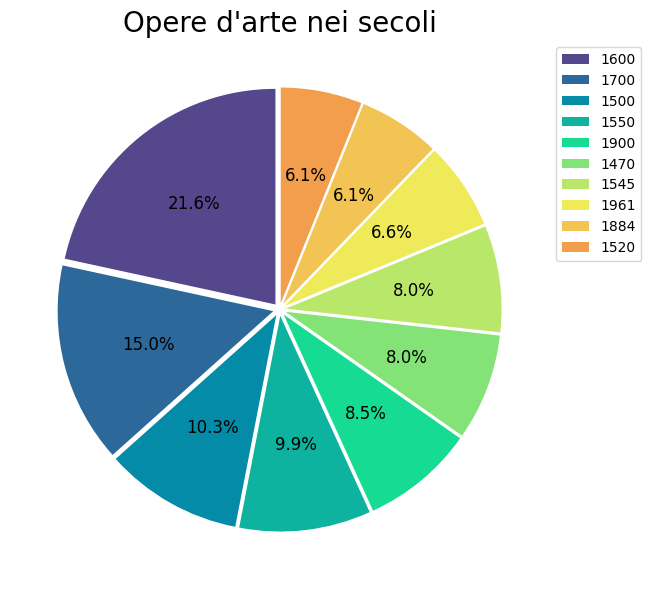

In [ ]:
ax = df['data_creazione'].value_counts().head(10).plot.pie(figsize=(7,7),
    explode=(0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03),
    pctdistance=0.6,
    autopct='%1.1f%%',
    ylabel='',
    startangle=90,
    labeldistance=None,
    textprops={'fontsize': 12, 'color': 'black'},
    colors=["#54478c","#2c699a","#048ba8","#0db39e","#16db93","#83e377","#b9e769","#efea5a","#f1c453","#f29e4c"],
    legend=False,
);

ax.set_title("Opere d'arte nei secoli", fontsize=20)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=10)

### 5.2 Indagine sui generi

Dopo aver analizzato in che secolo fossero state realizzate più opere d'arte, abbiamo deciso di indagare sul genere che le caratterizzava.
Il genere era uno degli aspetti che ci aveva incuriosito maggiormente e che quindi già dall'osservazione preliminare avevamo deciso di prendere in considerazione.

Dopo il conteggio dei valori unici, avevamo anche visto che la colonna "generi" era quella che presentava il minor numero rispetto alle altre, 48 per la precisione. Dunque questo significava un'indagine più mirata, con la maggior parte dei valori già accorpati in categorie specifiche e quindi anche più facili da analizzare.

Abbiamo quindi iniziato la nostra indagine filtrando solo la colonna scelta col metodo **.filter()**. Da questa nuova tabella, di cui erano mostrate solo le prime e le ultime righe, abbiamo avuto la conferma che molti valori comparivano ripetuti diverse volte.

In [ ]:
df.filter(["generi"])

,generi
0,ritratto
1,nudo artistico; pittura mitologica
2,ritratto; ritratto di gruppo
3,arte religiosa
4,allegoria; pittura mitologica
...,...
2439,nudo artistico; pittura mitologica
2440,ritratto
2441,arte di genere
2442,arte religiosa


Dopo aver filtrato la colonna, abbiamo fatto il conto di tutti i generi presenti con **.value_counts()** e osservando i risultati ottenuti abbiamo notato che i primi risultati corrispondevano a generi ben definiti, procedendo con la lettura invece si notavano sempre più sottogenenri che andavano a sommarsi col genere principale come la "pittura mitologica" che poi veniva unito a "nudo artistico" e "allegoria".

In [ ]:
df['generi'].value_counts()

,count
generi,
arte religiosa,807
ritratto,432
pittura mitologica,62
arte di genere,46
autoritratto,38
pittura paesaggistica,16
allegoria,15
paesaggio urbano,14
pittura storica,13


A fronte di quanto detto fino ad ora, abbiamo deciso di soffermarci su altri generi, all'apparenza più problematici, ovvero "ritratto" e "autoritratto". Abbiamo quindi iniziato ad analizzarli meglio, prima conteggiando il numero di opere catalogate in relazione con l'anno di maggior produttività artistica, in modo da fare un confronto col risultato dell'analisi già svolta in precedenza.
Questa operazione l'abbiamo ripetuta per entrambe le categorie.





In [ ]:
ritratti = df[df["generi"] == "ritratto"]
conteggio = ritratti["data_creazione"].value_counts()
print(conteggio)

data_creazione
1545    10
1900     9
1550     9
1600     8
1560     7
        ..
1656     1
1823     1
1673     1
1588     1
1898     1
Name: count, Length: 221, dtype: Int64


In [ ]:
autoritratti = df[df["generi"] == "autoritratto"]
conteggio = autoritratti["data_creazione"].value_counts()
print(conteggio)

data_creazione
1930    2
1790    2
1791    1
1542    1
1579    1
1669    1
1700    1
1784    1
1888    1
1914    1
1558    1
1646    1
1862    1
1682    1
1913    1
1906    1
1907    1
1793    1
1851    1
1720    1
1716    1
1655    1
1911    1
1900    1
1675    1
1910    1
1868    1
1625    1
1944    1
1850    1
1732    1
1730    1
1580    1
1947    1
1895    1
1860    1
Name: count, dtype: Int64


A fronte di quanto emerso dal conteggio delle opere nei secoli, soprattutto analizzando lo sviluppo del ritratto, possiamo notare come ritorni un anno che era già emerso dall'analisi delle "opere nei secoli" ossia il 1545. Questo oltre ad essere stato il quinto anno più prolifico per le opere d'arte in generale risulta essere anche l'anno in cui sono stati prodotti più ritratti.

Da come si può notare dal conteggio degli "autoritratti" questo genere rimane costante negli anni (dal 1505 al 1947) senza mai prevalere sul primo o sugli altri generi.

Osservando le voci del conteggio generale abbiamo notato che compariva la dicitura "ritratto; autoritratto" e ci siamo chieste per quale motivo fossero state accorpate, essendo presenti anche come categorie singole. Abbiamo quindi estratto le due righe utilizzando il metodo **.loc[]** e inserito in due caselle di testo le immagini corrispondenti.


In [ ]:
df.loc[df["generi"] == "ritratto; autoritratto"]

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
301,http://www.wikidata.org/entity/q6696013,ritratto lucano,leonardo da vinci (maschio),1505,ritratto; autoritratto,vaglio basilicata,museo delle antiche genti di lucania,leonardo da vinci,NaN,leonardo da vinci,0.44,0.60
438,http://www.wikidata.org/entity/q45381203,bernardino campi ritrae sofonisba anguissola,NaN,1559,ritratto; autoritratto,pinacoteca nazionale di siena,pinacoteca nazionale di siena,sofonisba anguissola; bernardino campi,manierismo,NaN,1.08,1.09


Leonardo Da Vinci, *Ritratto lucano*, Museo delle antiche genti di Lucania, 1505

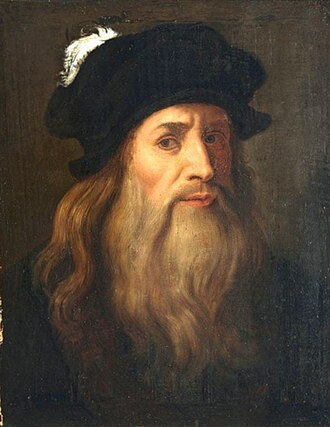

Sofonisba Anguissola, *Bernardino Campi ritrae Sofonisba Anguissola*, Pinacoteca Nazionale di Siena, 1559

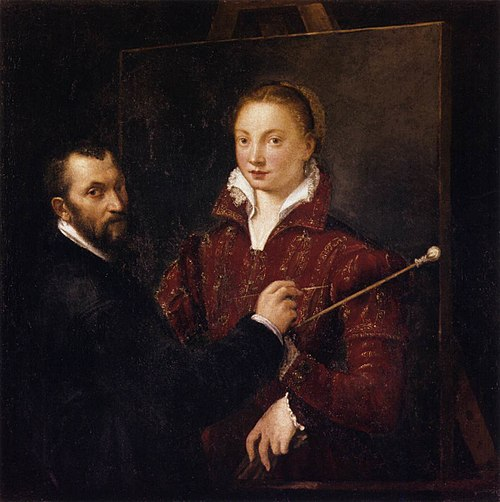

Dopo aver guardato bene le due opere, abbiamo deciso di modificare il "genere" dell'opera di Leonardo Da Vinci (riga 301) da "ritratto; autoritratto" solo con "autoritratto" in quanto secondo diversi studi il volto raffigurato sembrerebbe essere proprio quello dell'autore toscano, quindi più in linea con la seconda definizione.

La riga 438 invece non è stata modificata perchè rientra in entrambe le categorie siccome la presunta autrice, Sofonisba Anguissola, si autoritrae come soggetto del dipinto che Bernardino Campi, altro artista, qui sta realizzando.

Abbiamo quindi selezionato la riga 301 per modificarne il genere, sempre utilizzando la funzione **.loc[,]**.

Per verificare la riuscita dell'operazione abbiamo ricontato i generi.

In [ ]:
df.loc[301, 'generi'] = "autoritratto"
df['generi'].value_counts()

,count
generi,
arte religiosa,807
ritratto,432
pittura mitologica,62
arte di genere,46
autoritratto,39
pittura paesaggistica,16
allegoria,15
paesaggio urbano,14
pittura storica,13


Studiando però l'opera di Sofonisba Anguissola abbiamo riscontrato l'assenza dell'autore nella colonna "artisti", abbiamo quindi deciso di aggiungere anche questa informazione al Dataframe per una maggior completezza.

Abbiamo svolto la stessa operazione di prima andando ad agire sulla posizione interessata e poi abbiamo visualizzato col metodo **.index()** la riga corretta.

In [ ]:
df.loc[438, 'artisti'] = "sofonisba anguissola"
df.iloc[438]

,438
id,http://www.wikidata.org/entity/q45381203
titolo,bernardino campi ritrae sofonisba anguissola
artisti,sofonisba anguissola
data_creazione,1559
generi,ritratto; autoritratto
luoghi,pinacoteca nazionale di siena
collezioni,pinacoteca nazionale di siena
contenuti,sofonisba anguissola; bernardino campi
movimenti,manierismo
soggetti,NaN


Dopo aver corretto questi dati, abbiamo deciso di rivedere tutti i valori unici all'interno della colonna "generi" con il metodo **.unique()**, con lo scopo di modificare i generi accorpati in riferimento ad una singola opera.

In [ ]:
df['generi'].unique()

array(['ritratto', 'nudo artistico; pittura mitologica',
       'ritratto; ritratto di gruppo', 'arte religiosa',
       'allegoria; pittura mitologica',
       'nudo artistico; allegoria; portrait historié',
       'nudo artistico; arte religiosa', 'allegoria', 'paesaggio urbano',
       'pittura mitologica', 'arte di genere',
       'pittura storica; dipinti di battaglie', 'autoritratto',
       'autoritratto; pittura mitologica; portrait historié',
       'natura morta', 'autoritratto; arte religiosa', nan,
       'ritratto; pittura mitologica', 'dipinti di battaglie',
       'allegoria; arte religiosa', 'nudo artistico',
       'pittura paesaggistica', 'ritratto equestre', 'capriccio',
       'vedutismo', 'vedutismo; pittura paesaggistica', 'pittura storica',
       'pittura storica; purismo',
       'nudo artistico; arte di genere; arte religiosa',
       'ritratto; autoritratto',
       'paesaggio marino; pittura paesaggistica',
       'nudo artistico; pastorale', 'paesaggio mari

* **Abbiamo diviso i vari generi e sottogeneri solo a questo punto perché altrimenti non aveva senso modificare il valore nella riga 301.**

* Abbiamo creato una nuova variabile chiamata "generi_separati" per agire sulla colonna "generi" del DataFrame.
Con **.str.split('; ')** abbiamo diviso ogni stringa nella colonna 'generi' in una lista di stringhe, usando ";" come separatore perchè abbiamo notato che più generi erano accorpati insieme in una singola riga. Successivamente, con **.explode()** abbiamo trasformato ogni elemento di queste liste in una riga separata affinchè potessimo lavorare sui singoli valori.
Se prima un'opera aveva più generi, ora ognuno di questi appare su una riga distinta.

* Abbiamo poi stampato una stringa descrittiva e selezionato i primi 10 valori di "generi_separati".

* Infine, abbiamo osservato, con **.value_counts()**, quanti generi individuali ci fossero dopo la separazione.

* **Display()** mostra i primi 10 generi in anteprima dopo la separazione.

In [ ]:
generi_separati = df['generi'].str.split('; ').explode()

print("Esempio di generi dopo la separazione:")
display(generi_separati.head(10))

print("\nConteggio dei generi separati:")
display(generi_separati.value_counts().head(10))

Esempio di generi dopo la separazione:


,generi
0,ritratto
1,nudo artistico
1,pittura mitologica
2,ritratto
2,ritratto di gruppo
3,arte religiosa
4,allegoria
4,pittura mitologica
5,arte religiosa
6,arte religiosa



Conteggio dei generi separati:


,count
generi,
arte religiosa,821
ritratto,440
pittura mitologica,75
arte di genere,53
autoritratto,42
nudo artistico,23
pittura storica,21
pittura paesaggistica,19
allegoria,19


Per concludere questo passaggio abbiamo creato un grafico a barre orizzontali per visualizzare i dieci generi più utilizzati nel tempo.

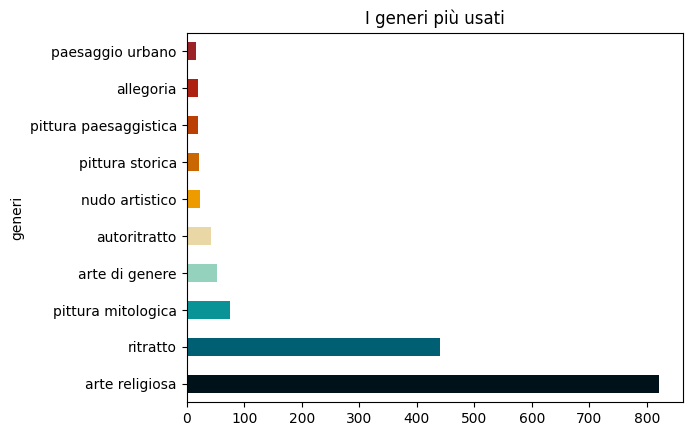

In [ ]:
grafico_a_barre1 = generi_separati.value_counts().head(10).plot.barh(
    title="I generi più usati",
    color=["#001219","#005f73","#0a9396","#94d2bd","#e9d8a6","#ee9b00","#ca6702","#bb3e03","#ae2012","#9b2226"]
    )

Dopo aver sistemato i valori accorpati, abbiamo deciso di svolgere un'ultima indagine per vedere in quali collezioni fossero presenti più ritratti.

Partendo dai generi_separati, abbiamo filtrato i valori contenenti solo il genere "ritratto" e, attraverso i metodi **.loc[]** e **.index**, abbiamo estratto gli indici corrispondenti per svolgere il conteggio corretto in relazione con le collezioni in cui le opere si trovano.

Stavolta abbiamo scelto di usare un grafico a barre, per svilupparlo però è stato necessario creare una nuova variabile che tenesse conto del risultato appena ottenuto e che mostrasse solo le cinque collezioni col maggior numero di opere.

In [ ]:
ritratti_separati = generi_separati[generi_separati == 'ritratto']
#filtri da generi_separati tutte le voci che corrispondono a 'ritratto'

ritratti = df.loc[ritratti_separati.index] #con loc estrai la le righe del df corrispondenti a ritratto
# .index ti da la posizioe precisa in maniera alternativa rispetto a [riga, colonna]
conteggio_collezioni = ritratti['collezioni'].value_counts() #per la posizione in cui si trova il ritratti, si prende il valore nella colonna collezioni e lo si conta
print(conteggio_collezioni)

collezioni
palazzo degli uffizi                                        52
galleria palatina                                           38
raccolte d'arte della pinacoteca civica di palazzo volpi    34
quadreria dell'ospedale di busto arsizio                    25
museo nazionale di capodimonte                              17
                                                            ..
museo civico di bassano                                      1
galleria sabauda                                             1
collezione chigi; palazzo chigi                              1
museo di castelvecchio                                       1
accademia carrara; palazzo frizzoni                          1
Name: count, Length: 130, dtype: int64


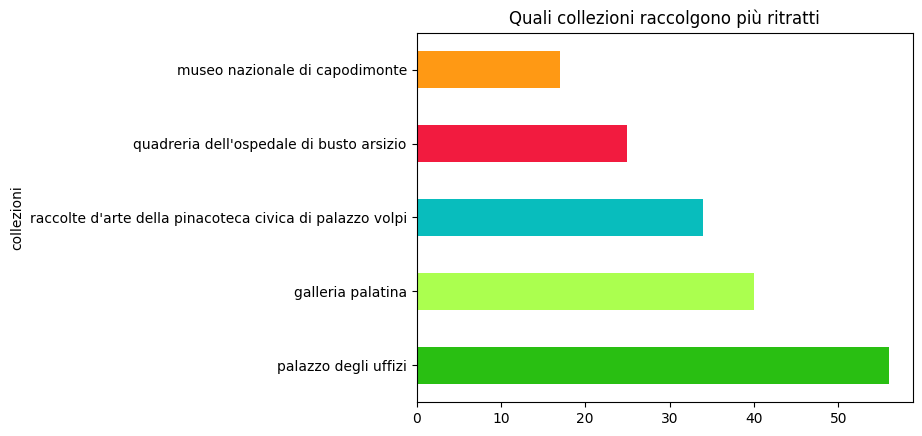

In [ ]:
conteggio_collezioni_ritratti = ritratti['collezioni'].str.split('; ').explode()
grafico_a_barre = conteggio_collezioni_ritratti.value_counts().head(5).plot.barh(
    title="Quali collezioni raccolgono più ritratti",
    color=["#29bf12","#abff4f","#08bdbd","#f21b3f","#ff9914"]
    )

### 5.3 Indagine sui movimenti artistici

Come ulteriore indagine, abbiamo voluto prendere in considerazione la colonna dei movimenti artistici, colonna che si presentava colma di nozioni che non seguiva un metodo di catalogazione univoco. Siamo quindi volute intervenire per mettere ordine a questa sezione.
In particolare ricorrevano molte voci legate al periodo del rinascimento come: "alto rinascimento", "primo rinascimento", "protorinascimento", "rinascimento", "pittura rinascimentale italiana", "rinascimento italiano", ... Tutte diciture in disaccordo tra loro che abbiamo voluto rendere univoche e standardizzate per creare meno confusione nella lettura della tabella.

Ovviamente questo ha portato a scelte di catalogazione molto rigide, i movimenti e i periodi sono stati scelti e suddivisi in maniera arbitraria sulla base di quanto riportato già nel DataFrame, si sono scelti i movimenti più usati a discapito di quelli che invece comparivano solo un paio di volte, come "eclettismo" e "postmacchiaioli". Sono state eliminate anche gli stili locali in quanto non si poteva fare un collegamento a una specifica colonna "luogo_creazione" che sarebbe stata utile per altri stili come quello fiammingo o il rococò che hanno un tempo e un luogo precisi nella loro storia.

In [ ]:
df['movimenti'].value_counts()

,count
movimenti,
pittura veneta,68
alto rinascimento,41
primo rinascimento,34
manierismo,32
barocco,27
pittura veneta; alto rinascimento,23
pittura rinascimentale italiana,19
protorinascimento,14
rinascimento italiano,13


In [ ]:
df['movimenti'].str.lower()

,movimenti
0,alto rinascimento
1,rinascimento; primo rinascimento
2,manierismo; pittura veneta
3,rinascimento italiano
4,primo rinascimento
...,...
2439,NaN
2440,NaN
2441,pittura veneta
2442,NaN


Per modificare tutti i valori della colonna "movimenti" abbiamo scelto di utilizzare il ***for loop*** in modo che ogni volta venisse analizzato il valore contenuto nella cella in base alle condizioni scelte e col metodo **.iterrows()** è stato possibile far iterare il ciclo in autonomia.

Il codice modifica i valori della colonna "movimenti" in base all'anno di creazione, riferibile alla colonna "data_creazione". In questo modo sono state poste delle condizioni precise per l'assegnazione di valori che rendono univoca la catalogazione.

Grazie all'utilizzo del metodo **pd.isna()** è stato possibile leggere e analizzare anche le celle in cui il valore non era definito ma appariva le dicitura < NA >. In questo modo è stato possibile prendere in considerazione il DataFrame completo.

Per modificare invece la cella precisa nella colonna scelta, abbiamo utilizzato il metodo **.at[,]** che identifica la posizione grazie alla variabile "riga", iterata ogni volta grazie al ciclo, e legata alla colonna "movimenti".

In [ ]:
for i, riga in df.iterrows(): #il for itera per ogni indice i ogni riga del DataFrame
  anno = riga['data_creazione'] #alla variabile anno viene assegnato il valore corrispondente a "data creazione" per ogni riga del df
  if pd.isna(anno): #se nel df ad anno corrispondono dei valori nulli, con questo metodo python li riconosce ed elabora la risposta
    df.at[i,'movimenti']= "movimento sconosciuto" #con il metodo .at[,] per ogni indice corrisponde un valore in "movimenti" che viene modificato in base alla condizione assegnata
  elif 0 < anno and anno < 1250:
    df.at[i,'movimenti']= "arte medievale"
  elif anno >= 1250 and anno < 1400:
    df.at[i,'movimenti']= "protorinascimento"
  elif anno >= 1400 and anno < 1520:
    df.at[i,'movimenti']= "rinascimento"
  elif anno >= 1520 and anno < 1600:
    df.at[i,'movimenti']= "manierismo"
  elif anno >= 1600 and anno < 1750:
    df.at[i,'movimenti']= "barocco"
  elif anno >= 1750 and anno < 1800:
    df.at[i,'movimenti']= "neoclassicismo"
  elif anno >= 1800 and anno < 1850:
    df.at[i,'movimenti']= "romanticismo"
  elif anno >= 1850 and anno < 1870:
    df.at[i,'movimenti']= "realismo"
  elif anno >= 1870 and anno < 1890:
    df.at[i,'movimenti']= "impressionismo"
  elif anno >= 1890 and anno < 1910:
    df.at[i,'movimenti']= "art nouveau"
  elif anno >= 1910 and anno < 1930:
    df.at[i,'movimenti']= "futurismo"
  else:
    df.at[i,'movimenti']= "arte contemporanea"

Per rendere visibili le modifiche fatte, abbiamo mostrato nuovamente le prime righe del DataFrame che mostrano la colonna "movimenti" piena del valore univoco "rinascimento" invece che come in precedenza "alto rinascimento" o "primo rinascimento".

In [ ]:
df.head()

,id,titolo,artisti,data_creazione,generi,luoghi,collezioni,contenuti,movimenti,soggetti,altezza,larghezza
0,http://www.wikidata.org/entity/q428274,"ritratto di fedra inghirami, detto fedra",raffaello sanzio (maschio),1510,ritratto,galleria palatina,galleria palatina,libro; carta; scrittura; strabismo; posizione ...,rinascimento,tommaso inghirami,0.910,0.610
1,http://www.wikidata.org/entity/q151047,nascita di venere,sandro botticelli (maschio),1485,nudo artistico; pittura mitologica,NaN,palazzo degli uffizi,mare; donna; cielo; vento; albero; afrodite; c...,rinascimento,venere anadiomene; nascita di afrodite,1.725,2.785
2,http://www.wikidata.org/entity/q180632,ritratto di paolo iii con i nipoti alessandro ...,tiziano vecellio (maschio),1546,ritratto; ritratto di gruppo,museo nazionale di capodimonte,museo nazionale di capodimonte,tavolo; tenda; papa paolo iii; ottavio farnese...,manierismo,papa paolo iii,2.100,1.760
3,http://www.wikidata.org/entity/q368788,pietà,perugino (maschio),1483,arte religiosa,palazzo degli uffizi,palazzo degli uffizi,gesù; donna; maria; uomo,rinascimento,pietà,1.680,1.760
4,http://www.wikidata.org/entity/q549847,primavera,sandro botticelli (maschio),1480,allegoria; pittura mitologica,palazzo medici riccardi; galleria delle pittur...,palazzo degli uffizi,mela; donna; fiore; mercurio; primavera; cupid...,rinascimento,primavera,2.070,3.190


Abbiamo ricontato i valori specifici dopo la modifica e poi creato il garfico per mostrare il risultato ottenuto.

Visto che il valore "movimento sconosciuto" compare quasi nella metà dei casi, abbiamo scelto di filtrare il DataFrame per non contarlo tra le voci del grafico e visualizzare solo i movimenti artistici definiti.

In [ ]:
df['movimenti'].value_counts()

,count
movimenti,
movimento sconosciuto,966
manierismo,359
barocco,337
rinascimento,300
arte contemporanea,74
impressionismo,72
art nouveau,64
protorinascimento,56
futurismo,56


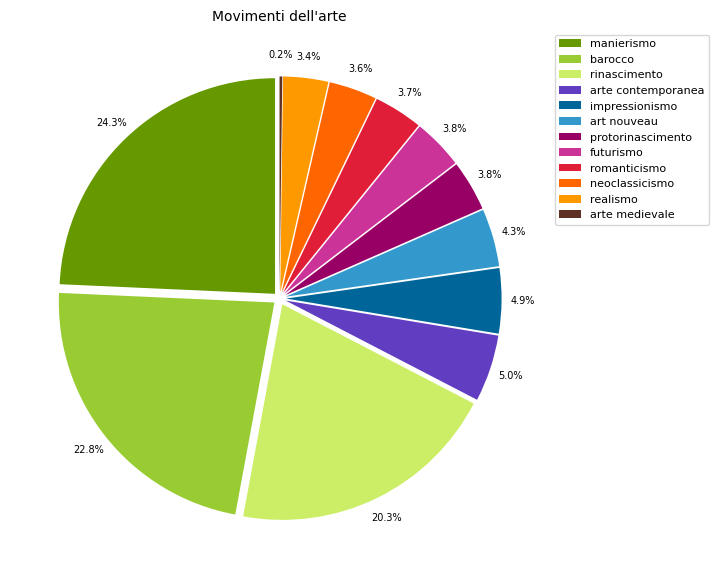

In [ ]:
df_filtered = df[df['movimenti'] != 'movimento sconosciuto']
ax = df_filtered['movimenti'].value_counts().head(12).plot.pie(figsize=(7,7),
    explode=(0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03),
    pctdistance=1.1, #il numero è 1.1 per far apparire le percentuali fuori dal grafico ed evitare la sovrapposizione di "realismo" e "arte medievale"
    autopct='%1.1f%%',
    ylabel='',
    startangle=90,
    labeldistance=None,
    colors=["#669900","#99cc33","#ccee66","#613dc1","#006699","#3399cc","#990066","#cc3399","#e01e37","#ff6600","#ff9900","#5e3023"],
    textprops={'fontsize': 7, 'color': 'black'},
    legend=False, # Legenda come "false" in modo da averla spostata rispetto a fetta di grafico
);

ax.set_title("Movimenti dell'arte", fontsize=10)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)

Come mostra il grafico a torta qui sopra i movimenti artistici che più di tutti hanno raccolgono più opere d'arte sono: Manierismo (24.3%), Barocco (22.8%) e Rinascimento (20.3%).

Dato i risultati ottenuti abbiamo voluto aggiungere un'analisi per conoscere chi fossero gli artisti più produttivi nei tre momenti identificati.

Per fare ciò abbiamo creato una nuova variabile chiamata "movimento" che estrae tutti i valori corrispendenti a "manierismo" dalla colonna "movimenti". Con la variabile "conteggio_artisti" abbiamo messo in relazione il risultato del passaggio precedente con la colonna "artisti" e con **.value_counts()** ne abbiamo contato il numero.

Abbiamo eseguito lo stesso passaggio anche per il Barocco e il Rinascimento.

In [ ]:
movimento = df[df["movimenti"] == "manierismo"]
conteggio_artisti = movimento["artisti"].value_counts()
print (conteggio_artisti)

artisti
tiziano vecellio (maschio)             47
jacopo tintoretto (maschio)            24
agnolo bronzino (maschio)              21
federico barocci (maschio)             11
cristofano dell'altissimo (maschio)    11
                                       ..
emanuel amberger (maschio)              1
gian paolo cavagna (maschio)            1
orlando flacco (maschio)                1
orazio vecellio (maschio)               1
giovanni cariani (maschio)              1
Name: count, Length: 116, dtype: int64


In [ ]:
movimento = df[df["movimenti"] == "barocco"]
conteggio_artisti = movimento["artisti"].value_counts()
print (conteggio_artisti)

artisti
caravaggio (maschio)                   24
guercino (maschio)                     11
giovanni battista pittoni (maschio)    10
antoon van dyck (maschio)               9
justus sustermans (maschio)             8
                                       ..
giovanni andrea ansaldo (maschio)       1
pietro paolo veglia (maschio)           1
francesco botti (maschio)               1
lambert sustris (maschio)               1
giovanni cariani (maschio)              1
Name: count, Length: 153, dtype: int64


In [ ]:
movimento = df[df["movimenti"] == "rinascimento"]
conteggio_artisti = movimento["artisti"].value_counts()
print (conteggio_artisti)

artisti
sandro botticelli (maschio)             36
raffaello sanzio (maschio)              14
giovanni bellini (maschio)              14
tiziano vecellio (maschio)              14
perugino (maschio)                      10
                                        ..
antonello da messina (maschio)           1
benvenuto tisi da garofalo (maschio)     1
michele giambono (maschio)               1
bernardino luini (maschio)               1
marco basaiti (maschio)                  1
Name: count, Length: 118, dtype: int64


Con le analisi precedenti sulle opere d'arte e la produzione di ritratti nel tempo ci è sempre risultato come periodo più prolifico il Cinquecento. Sulla base di ciò abbiamo voluto verificare chi avesse realizzato più ritratti, presumendo però che l'artista in questione fosse Tiziano.

Abbiamo quindi lavorato su tre codici per svolgere questa analisi mettendo in relazione dati di colonne differenti. Nel primo caso abbiamo semplicemente trovato l'artista che avesse creato più ritratti in generale, nel secondo chi fosse stato il più prolifico durante il Manierismo. Per concludere abbiamo cercato chi avesse prodotto più ritratti nel 1545, anno che era risultato essere il principale per questo genere.

Questo codice trova tutte le opere che appartengono al genere ritratto e conta gli artisti che le hanno prodotte.

In [ ]:
ritratto = df[df["generi"] == "ritratto"]
conteggio_artisti = ritratto["artisti"].value_counts()
print (conteggio_artisti)

artisti
tiziano vecellio (maschio)                     25
agnolo bronzino (maschio)                      14
cristofano dell'altissimo (maschio)            12
raffaello sanzio (maschio)                      8
antoon van dyck (maschio)                       7
                                               ..
giulio aristide sartorio (maschio)              1
pietro paolo veglia (maschio)                   1
orlando flacco (maschio)                        1
domenico robusti (maschio)                      1
giuseppe riva (pittore 1861-1948) (maschio)     1
Name: count, Length: 182, dtype: int64


In questa cella per trovare gli artisti che hanno prodotto ritratti durante il Manierismo.

In [ ]:
ritratto =df[df['generi'] == 'ritratto']
movimento_ritratto = ritratto[df['movimenti'] == 'manierismo']
conteggio_artisti = movimento_ritratto['artisti'].value_counts()
print(conteggio_artisti)

artisti
tiziano vecellio (maschio)                                  22
agnolo bronzino (maschio)                                   13
cristofano dell'altissimo (maschio)                         11
jacopo tintoretto (maschio)                                  6
iacopino del conte (maschio)                                 5
alessandro allori (maschio)                                  4
giovan battista moroni (maschio)                             4
sebastiano del piombo (maschio)                              3
scipione pulzone (maschio)                                   3
federico barocci (maschio)                                   3
francesco salviati (maschio)                                 2
dosso dossi (maschio)                                        2
bernardino campi (maschio)                                   2
caravaggio (maschio)                                         2
lavinia fontana (femmina)                                    1
el greco (maschio)                             

/tmp/ipykernel_363/405249426.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  movimento_ritratto = ritratto[df['movimenti'] == 'manierismo']


Con questo codice abbiamo cercato gli artisti che hanno creato ritratti nel 1545, anno più prolifico per questo genere.

In [ ]:
ritratto =df[df['generi'] == 'ritratto']
data_ritratto = ritratto[df['data_creazione'] == 1545]
conteggio_artisti = data_ritratto['artisti'].value_counts()
print(conteggio_artisti)

artisti
tiziano vecellio (maschio)    7
agnolo bronzino (maschio)     2
Name: count, dtype: int64


/tmp/ipykernel_363/3178241606.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_ritratto = ritratto[df['data_creazione'] == 1545]


# 6. Conclusioni

Dopo questa attenta e curata analisi i risultati ottenuti hanno confermato quanto già intuito dopo la prima indagine.

È emerso che l'anno in cui si concentra il maggior numero di opere è il 1600, ma a ricorrere maggiormente nei dieci valori estratti anni appartenenti al sedicesimo secolo.

Per quanto riguarda i generi due si distinguono rispetto a tutti gli altri ossia "arte religiosa" con 807 opere e "ritratto" con 432 dipinti. Quest'ultimo ci incuriosiva particolarmente e abbiamo deciso di approfondire l'analisi. Infatti abbiamo scoperto che il maggior numero di ritratti è stato prodotto nel 1545, la maggior parte di opere appartenente a questo genere è custodita al palazzo degli Uffizi.

Infine ci siamo concentrate sulla colonna  dei movimenti, prima ordinandola e poi analizzando i dati al suo interno. Manierismo, Barocco e Rinascimento si confermano i movimenti artistici più prolifici. Per curiosità abbiamo voluto anche trovare chi fosse stato l'artista che maggiormente aveva dipinto più opere rispettivamente per ogni periodo e poi abbiamo cercato chi fosse l'artista che avesse realizzato più ritratti e come ipotizzato si è confermato essere Tiziano.
